# BAB 2 — Data Understanding
## Eksplorasi Sentinel-2 dan training polygon Jawa Timur


## 2.1 Inventaris 5 file input

**Pertanyaan:** file apa saja yang dimiliki, apakah dapat dibaca, dan apa tipe/CRS-nya.

In [ ]:
# DATA AKTUAL PROJECT — 2.1 inventaris via Python
import json
import os
import geopandas as gpd
import pandas as pd
import rasterio

DATA_DIR = "../data"
FILES = [
    "boundary_jatim.geojson",
    "s2_jatim.tif",
    "s2_jatim_metadata.json",
    "training_samples_jawa_timur.geojson",
    "training_samples_jawa_timur.gpkg",
]

hasil = []

for fn in FILES:
  p = os.path.join(DATA_DIR, fn)
  ada = os.path.exists(p)
  ukuran = os.path.getsize(p) if ada else -1
  bisa, info = False, "tidak dibaca"

  if ada:
    try:
      if fn.endswith(".tif"):
        with rasterio.open(p) as src:
          bisa, info = (
              True,
              f"raster count={src.count} dtype={src.dtypes[0]} crs={src.crs}",
          )
      elif fn.endswith(".json"):
        with open(p, encoding="utf-8") as f:
          d = json.load(f)
        bisa, info = True, f"json, kunci={sorted(d.keys())}"
      else:
        g = gpd.read_file(p, rows=2)
        bisa, info = True, f"vektor n_kolom={len(g.columns)} crs={g.crs}"
    except Exception as e:
      bisa, info = False, f"gagal dibaca: {type(e).__name__}"

  hasil.append({
      "Nama File": fn,
      "Ada": ada,
      "Ukuran (Byte)": ukuran,
      "Dapat Dibaca": bisa,
      "Info Detail": info,
  })

# Tampilkan sebagai DataFrame (Tabel)
df_inventaris = pd.DataFrame(hasil)
display(df_inventaris)

,Nama File,Ada,Ukuran (Byte),Dapat Dibaca,Info Detail
0,boundary_jatim.geojson,True,151929,True,vektor n_kolom=1 crs=EPSG:4326
1,s2_jatim.tif,True,1564425175,True,raster count=6 dtype=int16 crs=EPSG:32749
2,s2_jatim_metadata.json,True,543,True,"json, kunci=['aoi_file', 'bands', 'bbox', 'job..."
3,training_samples_jawa_timur.geojson,True,11045852,True,vektor n_kolom=6 crs=EPSG:4326
4,training_samples_jawa_timur.gpkg,True,4788224,True,vektor n_kolom=5 crs=EPSG:4326


**Interpretasi 2.1:** kelima file ada dan dapat dibaca. Boundary 1 kolom; raster 6 band int16 EPSG:32749; training 6 kolom (geojson) vs 5 kolom (gpkg), keduanya EPSG:4326. Ukuran byte hanya bukti keberadaan.

## 2.2 Boundary Jawa Timur

**Pertanyaan:** apakah isi `boundary_jatim.geojson` terbukti sebagai Jawa Timur, dan apakah cocok sebagai AOI/clipping? Apakah ada level kabupaten/kota?

DATA AKTUAL PROJECT: crs_tercatat = EPSG:4326 (GeoJSON umumnya tanpa CRS; bila None, bounds derajat di bawah yang menjadi bukti)
DATA AKTUAL PROJECT: n_features = 1
DATA AKTUAL PROJECT: geometry_type = ['MultiPolygon']
DATA AKTUAL PROJECT: kolom = ['geometry']
DATA AKTUAL PROJECT: kolom_nama_wilayah = tidak tersedia
DATA AKTUAL PROJECT: bounds lon [110.8988, 116.2701], lat [-8.7804, -5.0489]
DATA AKTUAL PROJECT: semua_geometri_valid = True
DATA AKTUAL PROJECT: luas (proyeksi EPSG:32749, asumsi sumber EPSG:4326 — dicatat) = 48014131107 m2
DATA AKTUAL PROJECT: level_kabupaten_kota = tidak terindikasi (satu fitur provinsi)


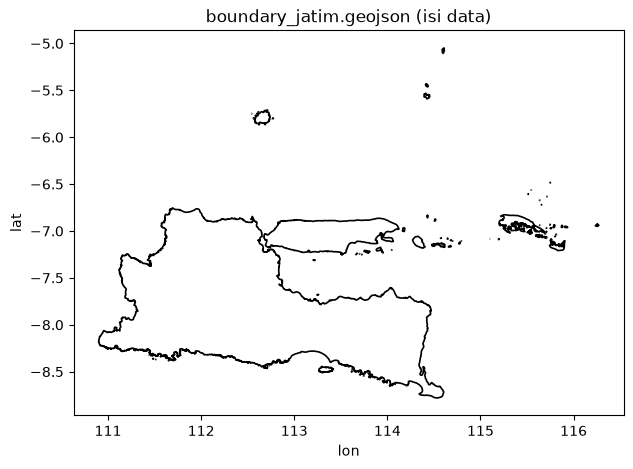

In [9]:
# DATA AKTUAL PROJECT — 2.2 boundary dari isi data.
import os

import geopandas as gpd
import matplotlib.pyplot as plt

bj = gpd.read_file("../data/boundary_jatim.geojson")
print(f"DATA AKTUAL PROJECT: crs_tercatat = {bj.crs} (GeoJSON umumnya tanpa CRS; bila None, bounds derajat di bawah yang menjadi bukti)")
print(f"DATA AKTUAL PROJECT: n_features = {len(bj)}")
print(f"DATA AKTUAL PROJECT: geometry_type = {bj.geometry.geom_type.unique().tolist()}")
print(f"DATA AKTUAL PROJECT: kolom = {list(bj.columns)}")
name_cols = [c for c in bj.columns if c.lower() in ("name", "nama", "provinsi", "province", "namobj")]
print(f"DATA AKTUAL PROJECT: kolom_nama_wilayah = {name_cols if name_cols else 'tidak tersedia'}")
b = bj.total_bounds
print(f"DATA AKTUAL PROJECT: bounds lon [{b[0]:.4f}, {b[2]:.4f}], lat [{b[1]:.4f}, {b[3]:.4f}]")
print(f"DATA AKTUAL PROJECT: semua_geometri_valid = {bool(bj.geometry.is_valid.all())}")
g4326 = bj.set_crs("EPSG:4326", allow_override=True) if bj.crs is None else bj.to_crs("EPSG:4326")
luas_m2 = float(g4326.to_crs("EPSG:32749").geometry.area.sum())
print(f"DATA AKTUAL PROJECT: luas (proyeksi EPSG:32749, asumsi sumber EPSG:4326 — dicatat) = {luas_m2:.0f} m2")
print(f"DATA AKTUAL PROJECT: level_kabupaten_kota = {'mungkin' if len(bj) > 1 else 'tidak terindikasi (satu fitur provinsi)'}")

os.makedirs("../outputs/figures", exist_ok=True)
ax = bj.plot(figsize=(8, 5), edgecolor="black", facecolor="none", linewidth=1.2)
ax.set_title("boundary_jatim.geojson (isi data)")
ax.set_xlabel("lon")
ax.set_ylabel("lat")
plt.savefig("../outputs/figures/boundary_jatim.png", dpi=110, bbox_inches="tight")
plt.show()

**Interpretasi 2.2:** satu fitur MultiPolygon yang valid, tanpa kolom nama wilayah (nama wilayah menjadi "tidak tersedia"). Bounds lon [110.90, 116.27], lat [-8.78, -5.05] berada pada rentang Jawa Timur; luas 48014131107 m2 (proyeksi EPSG:32749). Satu fitur berarti level provinsi saja — analisis per kabupaten/kota di Tahap 6 tidak dimungkinkan dari file ini.

## 2.3 Sentinel-2: profil raster dan metadata

**Pertanyaan:** berapa ukuran, band, CRS, resolusi, nodata, dan sebaran nilai aktual? Apakah B11/B12 sudah di-resample ke 10 m?

In [11]:
import rasterio
from IPython.display import display, Markdown

# Membaca header raster tanpa memuat data pixel
with rasterio.open("../data/s2_jatim.tif") as src:
    band_names = [src.descriptions[i] or f'Band {i + 1}' for i in range(src.count)]
    band_dict = dict(enumerate(band_names, start=1))
    
    # Menyusun data ke dalam format Markdown Table
    md_table = f"""
### 🛰️ Informasi Profil Header Raster (`s2_jatim.tif`)

| Properti Raster | Nilai / Keterangan |
| :--- | :--- |
| **Dimensi (Width x Height)** | `{src.width} x {src.height}` piksel |
| **Jumlah Band (Count)** | `{src.count}` |
| **Tipe Data (Dtype)** | `{src.dtypes[0]}` |
| **Sistem Koordinat (CRS)** | `{src.crs}` |
| **Nilai NoData** | `{src.nodata}` |
| **Resolusi Spasial (Res)** | `{src.res}` |
| **Affine Transform** | `{src.transform}` |
| **Batas Spasial (Bounds)** | `Left: {src.bounds.left}, Bottom: {src.bounds.bottom}, Right: {src.bounds.right}, Top: {src.bounds.top}` |
| **Pemetaan Indeks Band** | `{band_dict}` |
"""

display(Markdown(md_table))


### 🛰️ Informasi Profil Header Raster (`s2_jatim.tif`)

| Properti Raster | Nilai / Keterangan |
| :--- | :--- |
| **Dimensi (Width x Height)** | `59412 x 41323` piksel |
| **Jumlah Band (Count)** | `6` |
| **Tipe Data (Dtype)** | `int16` |
| **Sistem Koordinat (CRS)** | `EPSG:32749` |
| **Nilai NoData** | `-32768.0` |
| **Resolusi Spasial (Res)** | `(10.0, 10.0)` |
| **Affine Transform** | `| 10.00, 0.00, 488850.00|
| 0.00,-10.00, 9440820.00|
| 0.00, 0.00, 1.00|` |
| **Batas Spasial (Bounds)** | `Left: 488850.0, Bottom: 9027590.0, Right: 1082970.0, Top: 9440820.0` |
| **Pemetaan Indeks Band** | `{1: 'B02', 2: 'B03', 3: 'B04', 4: 'B08', 5: 'B11', 6: 'B12'}` |


In [15]:
import numpy as np
import rasterio
from rasterio.windows import Window
from IPython.display import display, Markdown, HTML

STRIDE, KEEP_EVERY, BW = 20, 10, 2048
with rasterio.open("../data/s2_jatim.tif") as src:
    nd = src.nodata
    nama = [src.descriptions[i] or f"band_{i + 1}" for i in range(src.count)]
    nv = np.zeros(src.count, dtype=np.int64)
    nn = np.zeros(src.count, dtype=np.int64)
    s1 = np.zeros(src.count)
    s2 = np.zeros(src.count)
    mn = np.full(src.count, np.inf)
    mx = np.full(src.count, -np.inf)
    keep = [[] for _ in range(src.count)]
    
    for r in range(0, src.height, BW):
        for c in range(0, src.width, BW):
            arr = src.read(window=Window(c, r, min(BW, src.width - c), min(BW, src.height - r)))
            sub = arr[:, ::STRIDE, ::STRIDE]
            for b_ in range(src.count):
                v = sub[b_]
                m = v != nd
                nv[b_] += int(m.sum())
                nn[b_] += int((~m).sum())
                vv = v[m].astype(np.float64)
                if vv.size:
                    s1[b_] += vv.sum()
                    s2[b_] += np.square(vv).sum()
                    mn[b_] = min(mn[b_], float(vv.min()))
                    mx[b_] = max(mx[b_], float(vv.max()))
                    keep[b_].append(vv[::KEEP_EVERY])

    # Menyusun baris tabel untuk Markdown
    table_rows = []
    fraksi_str = f"Fraksi Sampel = 1/{STRIDE * STRIDE} (Persentil ~1/{STRIDE * STRIDE * KEEP_EVERY})"
    
    for b_ in range(src.count):
        kk = np.concatenate(keep[b_]) if keep[b_] else np.array([])
        mean = s1[b_] / nv[b_] if nv[b_] else float("nan")
        var = s2[b_] / nv[b_] - mean ** 2 if nv[b_] else float("nan")
        pct = np.percentile(kk, [1, 5, 25, 50, 75, 95, 99]) if kk.size else [float("nan")] * 7
        
        std_val = np.sqrt(max(var, 0))
        p_str = ", ".join([f"{p:.1f}" for p in pct])
        
        row = f"| `{nama[b_]}` | `{nv[b_]:,}` | `{nn[b_]:,}` | `{mn[b_]:.0f}` | `{mx[b_]:.0f}` | `{mean:.1f}` | `{std_val:.1f}` | `{p_str}` |"
        table_rows.append(row)

    # Render tampilan tabel yang bersih menggunakan IPython Markdown
    markdown_output = f"""
### Statistik Per Band (`s2_jatim.tif`)
* **Metode Sampling:** {fraksi_str} (Bukan sensus penuh)

| Band | Valid Pixels | NoData Pixels | Min | Max | Mean | Std | Percentiles (1, 5, 25, 50, 75, 95, 99) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :--- |
""" + "\n".join(table_rows)

display(Markdown(markdown_output))


### Statistik Per Band (`s2_jatim.tif`)
* **Metode Sampling:** Fraksi Sampel = 1/400 (Persentil ~1/4000) (Bukan sensus penuh)

| Band | Valid Pixels | NoData Pixels | Min | Max | Mean | Std | Percentiles (1, 5, 25, 50, 75, 95, 99) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :--- |
| `B02` | `362,273` | `5,849,779` | `-999` | `18968` | `1132.4` | `1945.1` | `138.0, 194.0, 313.0, 470.0, 802.0, 5900.0, 9939.9` |
| `B03` | `362,273` | `5,849,779` | `-999` | `17736` | `1291.4` | `1768.5` | `224.0, 358.0, 543.0, 722.0, 1016.0, 5596.0, 9271.8` |
| `B04` | `362,273` | `5,849,779` | `-650` | `16888` | `1183.1` | `1756.1` | `135.5, 201.0, 348.0, 592.0, 1076.0, 5420.0, 9027.9` |
| `B08` | `362,273` | `5,849,779` | `-88` | `16184` | `3156.2` | `1491.5` | `426.0, 1240.0, 2330.0, 2978.0, 3632.0, 6077.8, 8896.0` |
| `B11` | `362,273` | `5,849,779` | `30` | `15379` | `2387.6` | `1329.9` | `306.0, 810.0, 1725.8, 2127.0, 2634.2, 5452.0, 7505.0` |
| `B12` | `362,273` | `5,849,779` | `8` | `15249` | `1568.4` | `1251.6` | `172.5, 430.0, 836.0, 1186.0, 1832.0, 4614.9, 6349.0` |

In [13]:
# DATA AKTUAL PROJECT — 2.3c metadata vs 0.5 + cek resample B11/B12 dari data.
import json

import rasterio

with open("../data/s2_jatim_metadata.json", encoding="utf-8") as f:
    meta = json.load(f)
print(f"DATA AKTUAL PROJECT: metadata = {json.dumps(meta, ensure_ascii=False)}")
print(f"DATA AKTUAL PROJECT: cocok_0.5 = {meta.get('tanggal_mulai') == '2025-09-01' and meta.get('tanggal_akhir') == '2025-09-02' and meta.get('temporal_extent') == ['2025-09-01', '2025-09-03']}")
with rasterio.open("../data/s2_jatim.tif") as src:
    rx, ry = float(src.res[0]), float(src.res[1])
    print(f"DATA AKTUAL PROJECT: resolusi_raster = ({rx}, {ry}) m; semua band satu grid -> " +
          f"{'B11/B12 tampil pada 10 m, indikasi di-resample (metode tidak tercatat di metadata)' if rx == 10 and ry == 10 else 'resolusi bukan 10 m — catat sebagai temuan'}")

DATA AKTUAL PROJECT: metadata = {"koleksi": "SENTINEL2_L2A", "tanggal_mulai": "2025-09-01", "tanggal_akhir": "2025-09-02", "temporal_extent": ["2025-09-01", "2025-09-03"], "komposit": "median", "bands": ["B02", "B03", "B04", "B08", "B11", "B12"], "max_cloud_cover_pct": 20, "bbox": {"west": 110.8988, "south": -8.7804, "east": 116.2701, "north": -5.0489, "crs": "EPSG:4326"}, "aoi_file": "boundary_jatim.geojson", "output": "s2_jatim.tif", "job_id": "j-26100607452343a2be0930a04fc04519"}
DATA AKTUAL PROJECT: cocok_0.5 = True
DATA AKTUAL PROJECT: resolusi_raster = (10.0, 10.0) m; semua band satu grid -> B11/B12 tampil pada 10 m, indikasi di-resample (metode tidak tercatat di metadata)


**Interpretasi 2.3:** indeks band 1-6 terpetakan ke B02/B03/B04/B08/B11/B12 dari deskripsi raster. Statistik dari sampel sistematik 1:400 (persentil ~1:4000) — bukan sensus penuh. Metadata cocok dengan blok 0.5. Semua band satu grid 10 m, sehingga B11/B12 (asli 20 m) terindikasi di-resample; metodenya "tidak tercatat di metadata".

## 2.4 Penjelasan band (acuan umum sensor — bukan data project)

Panjang gelombang pusat nominal S2A dan resolusi asli terverifikasi dari Copernicus SentiWiki (https://sentiwiki.copernicus.eu/web/s2-mission) dan sentinel-hub bands (https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/bands/):

| Band | Nama | Panjang gelombang pusat | Resolusi asli |
|---|---|---|---|
| B02 | Blue | 490 nm | 10 m |
| B03 | Green | 560 nm | 10 m |
| B04 | Red | 665 nm | 10 m |
| B08 | NIR | 842 nm | 10 m |
| B11 | SWIR1 | 1610 nm | 20 m |
| B12 | SWIR2 | 2190 nm | 20 m |

(S2B sedikit berbeda, mis. B12 ~2186/2202 nm; koleksi project L2A tanpa penanda satelit → dipakai nominal. Perbedaan S2A/S2B kecil relatif terhadap lebar pita.)

### B02 — Blue (490 nm, 10 m)
Posisi: tampak biru. Merepresentasikan hamburan atmosfer dan kecerahan perairan dangkal. Kegunaan: cenderung membantu membedakan air jernih vs keruh dan memberi dasar warna RGB. Keterbatasan: sensitif terhadap aerosol/awan tipis. Kaitan kelas: Laut vs Danau.

### B03 — Green (560 nm, 10 m)
Posisi: tampak hijau, puncak pantulan vegetasi. Merepresentasikan kehijauan vegetasi dan kekeruhan air. Kegunaan: pembilang NDWI (McFeeters), dasar RGB. Keterbatasan: vegetasi sehat vs berair bisa berdekatan nilainya. Kaitan kelas: Sawah, Lahan hijau, Danau.

### B04 — Red (665 nm, 10 m)
Posisi: tampak merah, serapan klorofil. Merepresentasikan serapan fotosintesis. Kegunaan: penyebut NDVI, dasar RGB. Keterbatasan: tanah terbuka kering juga tinggi di merah. Kaitan kelas: vegetasi vs lahan terbangun/tanah.

### B08 — NIR (842 nm, 10 m)
Posisi: inframerah dekat, pantulan struktur sel daun. Merepresentasikan biomassa/kerapatan vegetasi; air menyerap kuat (rendah). Kegunaan: pembilang NDVI, penyebut NDWI/NDBI. Keterbatasan: sawah tergenang menyerupai air. Kaitan kelas: semua kelas vegetasi vs air vs terbangun.

### B11 — SWIR1 (1610 nm, 20 m asli)
Posisi: SWIR pendek, sensitif kadar air. Merepresentasikan kelembapan vegetasi/tanah dan kecerahan area terbangun. Kegunaan: pembilang NDBI. Keterbatasan: asli 20 m (di-resample ke 10 m di project) sehingga tepi tajam tercampur. Kaitan kelas: Bangunan/Permukiman, Mangrove (basah), Sawah.

### B12 — SWIR2 (2190 nm, 20 m asli)
Posisi: SWIR panjang. Merepresentasikan kandungan air/tanah dan material kering. Kegunaan: cenderung membantu memisahkan lahan terbuka kering dari terbangun. Keterbatasan: sama seperti B11 soal resample; rentang dinamis kecil. Kaitan kelas: Bangunan/Permukiman vs lahan terbuka di dalam Lahan hijau.

## 2.5 Training polygon: kesetaraan file, distribusi kelas, provenance

**Pertanyaan:** apakah `.geojson` dan `.gpkg` berisi hal yang sama? Berapa polygon per kelas? Dari mana label berasal?

In [18]:
import geopandas as gpd
from IPython.display import display, Markdown

# Membaca file GeoJSON dan GPKG
gj = gpd.read_file("../data/training_samples_jawa_timur.geojson")
gp = gpd.read_file("../data/training_samples_jawa_timur.gpkg")

# Proses perhitungan sesuai logika asal
n_gj, n_gp = len(gj), len(gp)
cols = ["class_id", "class_name", "source", "source_class"]
sama = gj[cols].value_counts().sort_index().equals(gp[cols].value_counts().sort_index())
a_gj = float(gj.to_crs("EPSG:32749").geometry.area.sum())
a_gp = float(gp.to_crs("EPSG:32749").geometry.area.sum())

tab = gj.groupby(["class_id", "class_name"]).size().reset_index(name="jumlah_polygon").sort_values("class_id")

# Menyusun baris tabel untuk distribusi kelas
class_rows = []
for _, r in tab.iterrows():
    class_rows.append(f"| `{int(r['class_id'])}` | `{r['class_name']}` | `{int(r['jumlah_polygon']):,}` |")

class_table_str = "\n".join(class_rows)

# Menyusun output Markdown yang terstruktur
markdown_output = f"""
### Validasi Kesetaraan Dataset: GeoJSON vs GPKG

| Properti Perbandingan | GeoJSON | GeoPackage (GPKG) |
| :--- | :--- | :--- |
| **Jumlah Fitur (Row)** | `{n_gj:,}` | `{n_gp:,}` |
| **Sistem Koordinat (CRS)** | `{gj.crs}` | `{gp.crs}` |
| **Tipe Geometri** | `{gj.geometry.geom_type.unique().tolist()}` | `{gp.geometry.geom_type.unique().tolist()}` |
| **Luas Total (EPSG:32749)** | `{a_gj:,.2f} m²` | `{a_gp:,.2f} m²` |

* **Komposisi Atribut Identik:** `{str(sama).upper()}`
* **Batas Spasial (BBox GeoJSON):** `{gj.total_bounds.tolist()}`
* **Batas Spasial (BBox GPKG):** `{gp.total_bounds.tolist()}`

---

### Distribusi Jumlah Polygon per Kelas
| Class ID | Nama Kelas (`class_name`) | Jumlah Polygon |
| :---: | :--- | :---: |
{class_table_str}

* **Total Keseluruhan Polygon:** `{len(gj):,}`
"""

display(Markdown(markdown_output))


### Validasi Kesetaraan Dataset: GeoJSON vs GPKG

| Properti Perbandingan | GeoJSON | GeoPackage (GPKG) |
| :--- | :--- | :--- |
| **Jumlah Fitur (Row)** | `2,823` | `2,823` |
| **Sistem Koordinat (CRS)** | `EPSG:4326` | `EPSG:4326` |
| **Tipe Geometri** | `['Polygon']` | `['Polygon']` |
| **Luas Total (EPSG:32749)** | `14,000,943,115.65 m²` | `14,000,943,115.65 m²` |

* **Komposisi Atribut Identik:** `TRUE`
* **Batas Spasial (BBox GeoJSON):** `[110.84711491172106, -9.018333071924799, 116.49558636883204, -4.833228947181715]`
* **Batas Spasial (BBox GPKG):** `[110.84711491172106, -9.018333071924799, 116.49558636883204, -4.833228947181715]`

---

### Distribusi Jumlah Polygon per Kelas
| Class ID | Nama Kelas (`class_name`) | Jumlah Polygon |
| :---: | :--- | :---: |
| `1` | `Sawah` | `500` |
| `2` | `Bangunan / Permukiman` | `500` |
| `3` | `Mangrove` | `500` |
| `4` | `Lahan hijau` | `500` |
| `5` | `Laut` | `500` |
| `6` | `Danau` | `323` |

* **Total Keseluruhan Polygon:** `2,823`


**Interpretasi 2.5a (hasil geometri 1-6):** keenam kelas bertipe tunggal `Polygon` — tidak ada campuran ataupun MultiPolygon. GeoJSON dan GPKG sama-sama 2823 fitur dengan komposisi atribut (`class_id`, `class_name`, `source`, `source_class`) identik. Satu-satunya perbedaan kolom: `fid` hanya ada di GeoJSON (6 vs 5 kolom), sehingga acuan FID = file GeoJSON. Jumlah mentah per kelas: kelas 1-5 masing-masing 500 polygon, Danau 323 (total 2823) — angka sebelum saring validitas, bukan angka final.

In [45]:
# DATA AKTUAL PROJECT — 2.5b tabulasi provenance (kolom diperiksa dulu).
import geopandas as gpd
from IPython.display import display, Markdown

gj = gpd.read_file("../data/training_samples_jawa_timur.geojson", ignore_geometry=True)

columns_list = list(gj.columns)

if {"source", "source_class"} <= set(gj.columns):
    tab = (gj.groupby(["class_id", "class_name", "source", "source_class"])
             .size()
             .reset_index(name="n"))

    rows = []
    for _, r in tab.sort_values(["class_id", "n"], ascending=[True, False]).iterrows():
        rows.append(
            f"| {int(r['class_id'])} "
            f"| {r['class_name']} "
            f"| {r['source']} "
            f"| {r['source_class']} "
            f"| {int(r['n']):,} |"
        )

    table_content = "\n".join(rows)

    markdown_output = f"""### Tabulasi Provenance Dataset

**Daftar Kolom:** {columns_list}

| Class ID | Nama Kelas | Source | Source Class | Jumlah |
| :---: | :--- | :--- | :--- | :---: |
{table_content}
"""
else:
    markdown_output = f"""### Tabulasi Provenance Dataset

**Daftar Kolom:** {columns_list}

**Status:** Provenance tidak tersedia.
"""

display(Markdown(markdown_output))

### Tabulasi Provenance Dataset

**Daftar Kolom:** ['fid', 'class_id', 'class_name', 'source', 'source_class']

| Class ID | Nama Kelas | Source | Source Class | Jumlah |
| :---: | :--- | :--- | :--- | :---: |
| 1 | Sawah | Kementan | Ponorogo | 66 |
| 1 | Sawah | Kementan | Pacitan | 34 |
| 1 | Sawah | Kementan | Banyuwangi | 31 |
| 1 | Sawah | Kementan | Ngawi | 27 |
| 1 | Sawah | Kementan | Sampang | 26 |
| 1 | Sawah | Kementan | Bojonegoro | 25 |
| 1 | Sawah | Kementan | Jember | 24 |
| 1 | Sawah | Kementan | Nganjuk | 22 |
| 1 | Sawah | Kementan | Sumenep | 21 |
| 1 | Sawah | Kementan | Bangkalan | 18 |
| 1 | Sawah | Kementan | Madiun | 17 |
| 1 | Sawah | Kementan | Lamongan | 16 |
| 1 | Sawah | Kementan | Pamekasan | 16 |
| 1 | Sawah | Kementan | Pasuruan | 15 |
| 1 | Sawah | Kementan | Tuban | 15 |
| 1 | Sawah | Kementan | Magetan | 14 |
| 1 | Sawah | Kementan | Malang | 13 |
| 1 | Sawah | Kementan | Kediri | 12 |
| 1 | Sawah | Kementan | Trenggalek | 12 |
| 1 | Sawah | Kementan | Bondowoso | 11 |
| 1 | Sawah | Kementan | Probolinggo | 11 |
| 1 | Sawah | Kementan | Tulungagung | 11 |
| 1 | Sawah | Kementan | Blitar | 10 |
| 1 | Sawah | Kementan | Jombang | 6 |
| 1 | Sawah | Kementan | Situbondo | 6 |
| 1 | Sawah | Kementan | Lumajang | 5 |
| 1 | Sawah | Kementan | Sidoarjo | 4 |
| 1 | Sawah | Kementan | Gresik | 3 |
| 1 | Sawah | Kementan | Kota Blitar | 3 |
| 1 | Sawah | Kementan | Mojokerto | 3 |
| 1 | Sawah | Kementan | Kota Madiun | 1 |
| 1 | Sawah | Kementan | Kota Pasuruan | 1 |
| 1 | Sawah | Kementan | Kota Surabaya | 1 |
| 2 | Bangunan / Permukiman | BIG | Kampung Padat Teratur | 100 |
| 2 | Bangunan / Permukiman | BIG | Perumahan Padat | 94 |
| 2 | Bangunan / Permukiman | BIG | Kampung Padat Tidak Teratur | 87 |
| 2 | Bangunan / Permukiman | BIG | Perumahan Jarang | 77 |
| 2 | Bangunan / Permukiman | BIG | Kampung Jarang Teratur | 74 |
| 2 | Bangunan / Permukiman | BIG | Kampung Jarang Tidak Teratur | 68 |
| 3 | Mangrove | BIG | Mangrove Sedang | 297 |
| 3 | Mangrove | BIG | Mangrove Lebat | 171 |
| 3 | Mangrove | BIG | Mangrove Jarang | 32 |
| 4 | Lahan hijau | BIG | Hutan Belukar | 127 |
| 4 | Lahan hijau | BIG | Hutan Sejenis | 60 |
| 4 | Lahan hijau | BIG | Perkebunan Sudah Menghasilkan | 54 |
| 4 | Lahan hijau | BIG | Semak | 54 |
| 4 | Lahan hijau | BIG | Perkebunan Belum Menghasilkan | 53 |
| 4 | Lahan hijau | BIG | Padang Rumput | 46 |
| 4 | Lahan hijau | BIG | Kebun Campuran | 41 |
| 4 | Lahan hijau | BIG | Tegalan/Ladang | 38 |
| 4 | Lahan hijau | BIG | Alang – Alang | 13 |
| 4 | Lahan hijau | BIG | Kebun Sayuran | 7 |
| 4 | Lahan hijau | BIG | Kebun Buah-buahan | 4 |
| 4 | Lahan hijau | BIG | Hutan Kota | 2 |
| 4 | Lahan hijau | BIG | Kebun Biofarmaka/Tumbuhan Obat | 1 |
| 5 | Laut | Natural Earth | ocean | 500 |
| 6 | Danau | BIG | Waduk | 323 |


**Provenance dan keterbatasan (dokumentasi 0.4, jujur).** Training sample dibentuk sendiri dari sumber sekunder memakai script sendiri (Kementan LBS2019 untuk Sawah; BIG Satupeta layer /5 dan /57 untuk Bangunan, Lahan hijau, Danau, Mangrove; Natural Earth `ne_10m_ocean` untuk Laut; OSM/Overpass untuk Danau/Waduk tambahan bila BIG < 50) — bukan survei lapangan. Parameter (`inner_buffer` per kelas agar pixel 10 m tidak mixed; `min_area` pasca-buffer; `CONFLICT_OVERLAP_FRAC=0.05`; `OVERSAMPLE=3`; exclusion pantai untuk Laut) hanya didokumentasikan, tidak dijalankan ulang. Keterbatasan: beda tahun (LBS2019 vs citra Sept 2025); snapshot 2 hari sehingga sawah bisa bera/panen/tergenang; garis pantai NE 10 m kasar; kemungkinan label noise; mixed pixel tepi; "Lahan hijau" ambigu; sebagian polygon tidak valid (diukur di 2.6, penyebab tidak ditebak). Label ini bukan pseudo-label model dan bukan ground truth lapangan.

## 2.6 Pemeriksaan validitas V1–V6 (diagnostik, bukan seleksi)

**Pertanyaan:** berapa polygon valid vs tidak valid per kelas dan per kode alasan? Pemilihan 50 per kelas dikerjakan di Tahap 3.

In [46]:
import numpy as np
import geopandas as gpd
from shapely.validation import explain_validity  # Diperbaiki dari shapely import explain_validity
from IPython.display import display, Markdown

EXPECTED = {1: "Sawah", 2: "Bangunan / Permukiman", 3: "Mangrove", 4: "Lahan hijau", 5: "Laut", 6: "Danau"}
g = gpd.read_file("../data/training_samples_jawa_timur.geojson")

n_total = len(g)
fid_unik = bool(g['fid'].is_unique)

g["kode"] = "VALID"
g["alasan"] = ""
m = g.geometry.isna() | g.geometry.is_empty
g.loc[m, "kode"] = "V1"; g.loc[m, "alasan"] = "geometri null/kosong"
dup = g.duplicated(subset=["fid"], keep=False) & (g["kode"] == "VALID")
g.loc[dup, "kode"] = "V1"; g.loc[dup, "alasan"] = "fid duplikat"

ok = g["kode"] == "VALID"
t = g.loc[ok, "geometry"].geom_type
m2 = ok & ~t.isin(["Polygon", "MultiPolygon"])
g.loc[m2, "kode"] = "V2"; g.loc[m2, "alasan"] = "tipe_" + t[m2].astype(str)

ok = g["kode"] == "VALID"
valid_geom = g.loc[ok, "geometry"].is_valid
m3 = ok & ~valid_geom.reindex(g.index, fill_value=True).fillna(False).astype(bool)
g.loc[m3, "kode"] = "V3"
for i in g.index[m3]:
    try:
        g.at[i, "alasan"] = str(explain_validity(g.at[i, "geometry"]))[:120]
    except Exception:
        g.at[i, "alasan"] = "invalid (alasan tidak terbaca)"

ok = g["kode"] == "VALID"
konsisten = g["class_id"].isin([1, 2, 3, 4, 5, 6]) & (g["class_name"] == g["class_id"].map(EXPECTED))
m4 = ok & ~konsisten
g.loc[m4, "kode"] = "V4"; g.loc[m4, "alasan"] = "label tidak lengkap/konsisten"

# V6: overlap lintas kelas > 0.05 dari luasnya
gm = g.loc[g["kode"] == "VALID", ["fid", "class_id", "geometry"]].copy()
gm = gm[gm.geometry.notna() & ~gm.geometry.is_empty].to_crs("EPSG:32749")
gm["area"] = gm.geometry.area
geom_of = dict(zip(gm["fid"], gm["geometry"]))
area_of = dict(zip(gm["fid"], gm["area"]))
v6 = set()
if len(gm):
    cand = gpd.sjoin(gm, gm, predicate="intersects", how="inner", lsuffix="l", rsuffix="r")
    cand = cand[(cand["fid_l"] != cand["fid_r"]) & (cand["class_id_l"] != cand["class_id_r"])]
    for fl, fr in zip(cand["fid_l"].tolist(), cand["fid_r"].tolist()):
        if geom_of[fl].intersection(geom_of[fr]).area > 0.05 * float(area_of[fl]):
            v6.add(fl)

g.loc[g["fid"].isin(v6) & (g["kode"] == "VALID"), "kode"] = "V6"
g.loc[g["kode"] == "V6", "alasan"] = "overlap lintas kelas > 0.05"

# Menyimpan output
import os
os.makedirs("../outputs/tables", exist_ok=True)
g.to_pickle("../outputs/tables/validity_v1v4v6.pkl")

# Menghitung jumlah per kriteria
v1_count = int((g['kode'] == 'V1').sum())
v2_count = int((g['kode'] == 'V2').sum())
v3_count = int((g['kode'] == 'V3').sum())
v4_count = int((g['kode'] == 'V4').sum())
v6_count = int((g['kode'] == 'V6').sum())
valid_count = int((g['kode'] == 'VALID').sum())

# V5: dibaca dari hasil hitung pixel (sel 2.6b); bila berkas belum ada -> dihitung di sel berikut.
import pandas as pd
try:
    _stat = pd.read_csv("../outputs/tables/polygon_pixel_stats.csv")
    _h = g[["fid", "kode"]].merge(_stat[["fid", "n_valid"]], on="fid", how="left")
    v5_count = int((((_h["kode"] == "VALID") & (_h["n_valid"] < 1)).sum()))
    v5_note = "(`n_valid<1`, termasuk gagal baca di luar extent)"
    valid_final = int((((_h["kode"] == "VALID") & (_h["n_valid"] >= 1)).sum()))
except FileNotFoundError:
    v5_count, v5_note, valid_final = None, "(dihitung di sel 2.6b berikut)", valid_count

# Format Output Tabel
markdown_output = f"""
### Hasil Validasi Geometri (V1 - V6)

* **Total Data (n_total):** `{n_total:,}`
* **FID Unik:** `{str(fid_unik).upper()}`
* **Status Penyimpanan:** Berhasil menyimpan ke `../outputs/tables/validity_v1v4v6.pkl`

| Kategori Validasi | Keterangan / Deskripsi Error | Jumlah Fitur |
| :--- | :--- | :---: |
| **V1** | Geometri null/kosong atau FID duplikat | `{v1_count:,}` |
| **V2** | Tipe geometri bukan Polygon / MultiPolygon | `{v2_count:,}` |
| **V3** | Geometri tidak valid (Topology Error) | `{v3_count:,}` |
| **V4** | Label kelas tidak lengkap atau tidak konsisten | `{v4_count:,}` |
| **V5** | Kurang dari 1 pixel valid {v5_note} | `{f"{v5_count:,}" if v5_count is not None else v5_note}` |
| **V6** | Overlap lintas kelas > 0.05 dari luas | `{v6_count:,}` |
| **VALID final** | Lolos V1-V6 (berpixel) | `{valid_final:,}` |
"""

display(Markdown(markdown_output))


### Hasil Validasi Geometri (V1 - V6)

* **Total Data (n_total):** `2,823`
* **FID Unik:** `TRUE`
* **Status Penyimpanan:** Berhasil menyimpan ke `../outputs/tables/validity_v1v4v6.pkl`

| Kategori Validasi | Keterangan / Deskripsi Error | Jumlah Fitur |
| :--- | :--- | :---: |
| **V1** | Geometri null/kosong atau FID duplikat | `0` |
| **V2** | Tipe geometri bukan Polygon / MultiPolygon | `0` |
| **V3** | Geometri tidak valid (Topology Error) | `0` |
| **V4** | Label kelas tidak lengkap atau tidak konsisten | `0` |
| **V5** | Kurang dari 1 pixel valid (`n_valid<1`, termasuk gagal baca di luar extent) | `2,008` |
| **V6** | Overlap lintas kelas > 0.05 dari luas | `47` |
| **VALID final** | Lolos V1-V6 (berpixel) | `768` |


In [23]:
# DATA AKTUAL PROJECT — 2.6b V5: hitung pixel valid per polygon (window/blok, centroid rule).
# Polygon invalid geometri: 'tidak dihitung'. Hanya pool ini yang dipakai di 2.7–2.10.
import numpy as np
import geopandas as gpd
import pandas as pd
import rasterio
from rasterio.features import geometry_mask
from rasterio.windows import from_bounds

g = pd.read_pickle("../outputs/tables/validity_v1v4v6.pkl")
TIF = "../data/s2_jatim.tif"
MAXSAMP_PER_POLY, MAXSAMP_PER_CLASS = 40, 6000
BANDS = ["B02", "B03", "B04", "B08", "B11", "B12"]
samp = {c: [] for c in [1, 2, 3, 4, 5, 6]}
n5, recs = 0, []
with rasterio.open(TIF) as src:
    nd = src.nodata
    gu = g.to_crs(src.crs)
    for _, row in gu.iterrows():
        fid, cid, geom = row["fid"], int(row["class_id"]), row["geometry"]
        if row["kode"] != "VALID" or geom is None or geom.is_empty or not geom.is_valid:
            recs.append((fid, -1, -1, "tidak dihitung (V1-V4/V6/invalid)"))
            continue
        try:
            w = from_bounds(*geom.bounds, src.transform).crop(src.height, src.width)
            if w.width <= 0 or w.height <= 0:
                raise ValueError("di luar extent")
            arr = src.read(window=w, boundless=True, fill_value=nd)
            m = geometry_mask([geom], out_shape=(arr.shape[1], arr.shape[2]),
                                transform=src.window_transform(w), invert=True, all_touched=False)
            okpx = m & (arr != nd).all(axis=0)
            n_valid = int(okpx.sum())
            n_nod = int(m.sum()) - n_valid
        except Exception as e:
            recs.append((fid, 0, 0, f"gagal baca: {type(e).__name__}"))
            continue
        if n_valid < 1:
            n5 += 1
            recs.append((fid, 0, n_nod, "V5: <1 pixel valid"))
        else:
            recs.append((fid, n_valid, n_nod, "ok"))
            vals = arr[:, okpx].T
            if len(samp[cid]) < MAXSAMP_PER_CLASS and n_valid:
                step = max(1, n_valid // MAXSAMP_PER_POLY)
                samp[cid].append(vals[::step][:MAXSAMP_PER_POLY])
stat = pd.DataFrame(recs, columns=["fid", "n_valid", "n_nodata", "status_v5"])
stat.to_csv("../outputs/tables/polygon_pixel_stats.csv", index=False)
np.savez("../outputs/tables/class_pixel_sample.npz", **{f"c{c}": np.concatenate(samp[c]) if samp[c] else np.zeros((0, 6), dtype=np.int16) for c in samp})
print(f"DATA AKTUAL PROJECT: polygon V5 (<1 pixel valid) = {n5}")
print("DATA AKTUAL PROJECT: tersimpan polygon_pixel_stats.csv + class_pixel_sample.npz")

DATA AKTUAL PROJECT: polygon V5 (<1 pixel valid) = 1901
DATA AKTUAL PROJECT: tersimpan polygon_pixel_stats.csv + class_pixel_sample.npz


In [26]:
# DATA AKTUAL PROJECT — 2.6c tabel validitas final per kelas x kode + contoh FID + pool vs 50.
import pandas as pd
from IPython.display import display, HTML

# LOAD & MERGE
g = pd.read_pickle("../outputs/tables/validity_v1v4v6.pkl")
stat = pd.read_csv("../outputs/tables/polygon_pixel_stats.csv")
g = g.merge(stat[["fid", "status_v5"]], on="fid", how="left")

g.loc[(g["kode"] == "VALID") & (g["status_v5"] == "V5: <1 pixel valid"), "kode"] = "V5"

# TABEL 1 — Crosstab validitas per kelas
ct = pd.crosstab(g["class_name"], g["kode"]).reset_index()

# Tambahkan baris TOTAL
total_row = {c: ct[c].sum() if c != "class_name" else "TOTAL" for c in ct.columns}
ct = pd.concat([ct, pd.DataFrame([total_row])], ignore_index=True)

print("TABEL 1 — Validitas per kelas × kode")
display(HTML(ct.to_html(index=False, justify="left", border=1)))

# TOTAL VALID
n_valid = int((g["kode"] == "VALID").sum())
print(f"\n✅ Total VALID = {n_valid} dari {len(g)} polygon")

# TABEL 2 — Contoh FID per kode
contoh = []
for kode in ["V1", "V2", "V3", "V4", "V5", "V6"]:
    fids = g.loc[g["kode"] == kode, "fid"].head(3).tolist()
    contoh.append({
        "kode": kode,
        "jumlah": int((g["kode"] == kode).sum()),
        "contoh_fid": ", ".join(map(str, fids)) if fids else "tidak ada"
    })
contoh_df = pd.DataFrame(contoh)

print("\nTABEL 2 — Contoh FID per kode")
display(HTML(contoh_df.to_html(index=False, justify="left", border=1)))

# TABEL 3 — Pool valid per kelas vs ambang 50
pool = (g.loc[g["kode"] == "VALID"]
          .groupby(["class_id", "class_name"])
          .size()
          .reset_index(name="n_valid"))
pool["status_50"] = pool["n_valid"].apply(lambda n: "✅ cukup" if n >= 50 else "⚠️ kurang")
pool["kekurangan"] = (50 - pool["n_valid"]).clip(lower=0)

print("\nTABEL 3 — Pool valid per kelas (ambang 50)")
display(HTML(pool.to_html(index=False, justify="left", border=1)))

# EXPORT
g[["fid", "class_id", "class_name", "kode", "alasan"]] \
    .to_csv("../outputs/tables/polygon_validity_diagnostic.csv", index=False)
print("\n💾 Tersimpan: polygon_validity_diagnostic.csv")

TABEL 1 — Validitas per kelas × kode


class_name,V5,V6,VALID
Bangunan / Permukiman,246,2,252
Danau,93,0,230
Lahan hijau,377,5,118
Laut,468,0,32
Mangrove,310,35,155
Sawah,407,5,88
TOTAL,1901,47,875



✅ Total VALID = 875 dari 2823 polygon

TABEL 2 — Contoh FID per kode


kode,jumlah,contoh_fid
V1,0,tidak ada
V2,0,tidak ada
V3,0,tidak ada
V4,0,tidak ada
V5,1901,"1, 2, 3"
V6,47,"43, 75, 79"



TABEL 3 — Pool valid per kelas (ambang 50)


class_id,class_name,n_valid,status_50,kekurangan
1,Sawah,88,✅ cukup,0
2,Bangunan / Permukiman,252,✅ cukup,0
3,Mangrove,155,✅ cukup,0
4,Lahan hijau,118,✅ cukup,0
5,Laut,32,⚠️ kurang,18
6,Danau,230,✅ cukup,0



💾 Tersimpan: polygon_validity_diagnostic.csv


**Interpretasi 2.6:** V1-V4 = 0 (tidak ada geometri null/duplikat/tipe salah/label inkonsisten). V6 = 47 polygon (terbanyak Mangrove: 35). V5 = 1901 polygon tanpa pixel valid — termasuk 107 yang gagal dibaca (di luar extent) namun masih berkode VALID dengan `n_valid=0`, sehingga Tahap 3 wajib memfilter `n_valid>0`, bukan hanya kode. Pool VALID final = 875 dari 2823; lima kelas mencapai ambang 50, Laut hanya 32 (kurang 18). Target 300 tidak tercapai — Tahap 3 memakai semua yang valid (maksimal 282) tanpa data baru.

## 2.7 Statistik polygon

**Pertanyaan:** seberapa besar polygon, adakah yang kosong/multipart, seberapa banyak overlap, dan apakah perkiraan pixel dari luas cocok dengan hitungan aktual?

In [29]:
# DATA AKTUAL PROJECT — 2.7 luas (EPSG:32749), ekstrem, overlap dalam/antar kelas, estimasi vs aktual.
import numpy as np
import pandas as pd
import geopandas as gpd
from IPython.display import display, HTML

# LOAD & REPROJECT
g = pd.read_pickle("../outputs/tables/validity_v1v4v6.pkl")
stat = pd.read_csv("../outputs/tables/polygon_pixel_stats.csv")

gm = g[g.geometry.notna() & ~g.geometry.is_empty].to_crs("EPSG:32749").copy()
gm["luas_m2"] = gm.geometry.area

# TABEL 1 — Ringkasan statistik luas total
ringkasan = pd.DataFrame({
    "Statistik": ["Minimum", "Maksimum", "Mean", "Median", "Std Dev", "Jumlah polygon"],
    "Luas (m2)": [
        f"{gm['luas_m2'].min():,.0f}",
        f"{gm['luas_m2'].max():,.0f}",
        f"{gm['luas_m2'].mean():,.0f}",
        f"{gm['luas_m2'].median():,.0f}",
        f"{gm['luas_m2'].std():,.0f}",
        f"{len(gm):,}",
    ],
})
print("TABEL 1 — Ringkasan statistik luas (EPSG:32749)")
display(HTML(ringkasan.to_html(index=False, justify="left", border=1)))

# TABEL 2 — Luas per kelas
agg = (gm.groupby(["class_id", "class_name"])["luas_m2"]
         .agg(["count", "min", "max", "mean", "median", "std"])
         .reset_index()
         .round(0))

agg.columns = ["class_id", "class_name", "count",
               "min_m2", "max_m2", "mean_m2", "median_m2", "std_m2"]

for c in ["min_m2", "max_m2", "mean_m2", "median_m2", "std_m2"]:
    agg[c] = agg[c].apply(lambda v: f"{v:,.0f}")

print("\nTABEL 2 — Luas per kelas")
display(HTML(agg.to_html(index=False, justify="left", border=1)))

# TABEL 3 — 5 polygon terkecil & 5 terbesar
kecil = gm.nsmallest(5, "luas_m2")[["fid", "class_id", "class_name", "luas_m2"]].copy()
besar = gm.nlargest(5, "luas_m2")[["fid", "class_id", "class_name", "luas_m2"]].copy()
kecil["luas_m2"] = kecil["luas_m2"].apply(lambda v: f"{v:,.0f}")
besar["luas_m2"] = besar["luas_m2"].apply(lambda v: f"{v:,.0f}")

print("\nTABEL 3a — 5 polygon terkecil")
display(HTML(kecil.to_html(index=False, justify="left", border=1)))

print("TABEL 3b — 5 polygon terbesar")
display(HTML(besar.to_html(index=False, justify="left", border=1)))

# TABEL 4 — Geometri multipart & kosong
n_multi  = int((gm.geometry.geom_type == "MultiPolygon").sum())
n_kosong = int((g.geometry.isna() | g.geometry.is_empty).sum())

geo_tab = pd.DataFrame({
    "Kategori": ["MultiPolygon", "Kosong / NA"],
    "Jumlah":   [f"{n_multi:,}", f"{n_kosong:,}"],
})
print("\nTABEL 4 — Tipe geometri khusus")
display(HTML(geo_tab.to_html(index=False, justify="left", border=1)))

# TABEL 5 — Overlap dalam kelas & antar kelas
cand = gpd.sjoin(
    gm[["fid", "class_id", "geometry"]],
    gm[["fid", "class_id", "geometry"]],
    predicate="intersects", how="inner",
    lsuffix="l", rsuffix="r",
)
cand = cand[cand["fid_l"] != cand["fid_r"]]

n_dalam = int((cand["class_id_l"] == cand["class_id_r"]).sum() // 2)
n_antar = int((cand["class_id_l"] != cand["class_id_r"]).sum() // 2)

ov_tab = pd.DataFrame({
    "Jenis overlap": ["Dalam kelas (intra-class)", "Antar kelas (inter-class)"],
    "Pasangan":      [f"{n_dalam:,}", f"{n_antar:,}"],
})
print("\nTABEL 5 — Pasangan polygon yang saling beririsan")
display(HTML(ov_tab.to_html(index=False, justify="left", border=1)))

# TABEL 6 — Estimasi vs aktual (rasio)
h = g[["fid", "class_id"]].merge(stat, on="fid", how="left")
h = h[h["n_valid"] >= 0].merge(gm[["fid", "luas_m2"]], on="fid", how="left")
h["estimasi"] = h["luas_m2"] / 100.0

rasio = (h["n_valid"] / h["estimasi"]).replace([np.inf, -np.inf], np.nan).dropna()

rasio_tab = pd.DataFrame({
    "Metrik":  ["Median rasio aktual / estimasi", "Jumlah sampel (n)"],
    "Nilai":   [f"{float(rasio.median()):.2f}", f"{len(rasio):,}"],
})
print("\nTABEL 6 — Estimasi vs aktual")
display(HTML(rasio_tab.to_html(index=False, justify="left", border=1)))

TABEL 1 — Ringkasan statistik luas (EPSG:32749)


Statistik,Luas (m2)
Minimum,0
Maksimum,"887,994,977"
Mean,"4,959,597"
Median,"15,092"
Std Dev,"19,485,207"
Jumlah polygon,"2,823"



TABEL 2 — Luas per kelas


class_id,class_name,count,min_m2,max_m2,mean_m2,median_m2,std_m2
1,Sawah,500,242,"3,702,821","171,754","20,269","468,333"
2,Bangunan / Permukiman,500,746,"1,837,869","38,678","9,405","127,070"
3,Mangrove,500,0,"3,937,649","42,751","1,976","232,428"
4,Lahan hijau,500,0,"887,994,977","2,643,215","15,838","40,617,340"
5,Laut,500,"24,980,010","25,207,223","25,057,673","25,056,562","56,701"
6,Danau,323,0,"3,352,297","74,017","3,485","359,825"



TABEL 3a — 5 polygon terkecil


...

Kategori,Jumlah
MultiPolygon,0
Kosong / NA,0



TABEL 5 — Pasangan polygon yang saling beririsan


Jenis overlap,Pasangan
Dalam kelas (intra-class),404
Antar kelas (inter-class),80



TABEL 6 — Estimasi vs aktual


Metrik,Nilai
Median rasio aktual / estimasi,0.00
Jumlah sampel (n),"2,776"


**Interpretasi 2.7:** luas menjulur ekstrem (minimum ~0 m2 berupa serpihan, maksimum ~888 juta m2 di Lahan hijau; median total 15092 m2). Multipart = 0 dan kosong = 0 — konsisten dengan V1-V2 = 0. Lima terkecil adalah serpihan sub-meter (Mangrove/Lahan hijau) yang praktis tidak memberi pixel. Overlap: 404 pasangan dalam kelas (dicatat, bukan pelanggaran) dan 80 antar kelas (disaring V6 bila >5%). Median rasio pixel aktual vs estimasi luas/100 m2 = 0,0 — sebagian besar polygon tidak menghasilkan pixel (V5).

## 2.8 Polygon menjadi pixel (inti)

**Pertanyaan:** bagaimana satu polygon menghasilkan baris-baris pixel? Bagaimana aturan centroid vs `all_touched`?

In [30]:
# DATA AKTUAL PROJECT — 2.8a contoh: FID 367 bila ada + satu contoh per kelas (valid, n_valid>0).
import pandas as pd

g = pd.read_pickle("../outputs/tables/validity_v1v4v6.pkl")
stat = pd.read_csv("../outputs/tables/polygon_pixel_stats.csv")
h = g.merge(stat, on="fid", how="left")
ada367 = 367 in set(h["fid"].tolist())
print(f"DATA AKTUAL PROJECT: FID 367 {'TERSEDIA' if ada367 else 'TIDAK TERSEDIA'}")
pool = h[(h["kode"] == "VALID") & (h["n_valid"] > 0)].sort_values("fid")
contoh = {}
for cid in [1, 2, 3, 4, 5, 6]:
    sub = pool[pool["class_id"] == cid]
    contoh[cid] = int(sub.iloc[0]["fid"]) if len(sub) else None
    print(f"DATA AKTUAL PROJECT: contoh class {cid} = FID {contoh[cid]}")
if ada367:
    r367 = h[h["fid"] == 367].iloc[0]
    print(f"DATA AKTUAL PROJECT: FID 367 class {int(r367['class_id'])} {r367['class_name']} kode={r367['kode']} n_valid={r367['n_valid']}")
pd.DataFrame([{"class_id": c, "fid": f} for c, f in contoh.items()]).to_csv("../outputs/tables/contoh_fid.csv", index=False)

DATA AKTUAL PROJECT: FID 367 TERSEDIA
DATA AKTUAL PROJECT: contoh class 1 = FID 0
DATA AKTUAL PROJECT: contoh class 2 = FID 500
DATA AKTUAL PROJECT: contoh class 3 = FID 1001
DATA AKTUAL PROJECT: contoh class 4 = FID 1500
DATA AKTUAL PROJECT: contoh class 5 = FID 2025
DATA AKTUAL PROJECT: contoh class 6 = FID 2552
DATA AKTUAL PROJECT: FID 367 class 1 Sawah kode=VALID n_valid=40



TABEL RINGKASAN — FID 367


Atribut,Nilai
FID,367
Class ID,1
Class name,Sawah
Luas (m2),"3,950"
Pixel valid (centroid),40
Pixel valid (all_touched),55
Pixel dalam geom tapi nodata,0


TABEL PIXEL — FID 367 (10 pertama dari 40)


pixel_id,row,col,B02,B03,B04,B08,B11,B12
0,38006,37397,289,562,404,2742,1714,968
1,38007,37396,310,596,390,2812,1605,820
2,38007,37397,312,540,412,2579,1714,968
3,38007,37398,241,472,293,2698,1714,968
4,38007,37399,339,544,406,3120,1969,1239
5,38007,37400,425,716,610,2719,1969,1239
6,38007,37401,720,722,870,1907,1937,1451
7,38007,37402,483,684,728,1980,1820,1249
8,38008,37396,331,570,424,2780,1655,887
9,38008,37397,317,550,426,2625,1721,1072


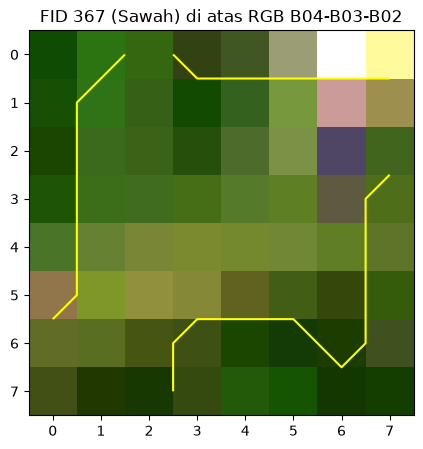


TABEL RINGKASAN — FID 0


Atribut,Nilai
FID,0
Class ID,1
Class name,Sawah
Luas (m2),"23,451"
Pixel valid (centroid),231
Pixel valid (all_touched),301
Pixel dalam geom tapi nodata,0


TABEL PIXEL — FID 0 (10 pertama dari 231)


pixel_id,row,col,B02,B03,B04,B08,B11,B12
0,34500,37629,276,501,366,2341,1824,1117
1,34501,37629,308,572,411,2656,2052,1273
2,34501,37630,223,465,319,2334,1554,809
3,34502,37629,388,650,540,2689,2052,1273
4,34502,37630,332,565,486,2380,1554,809
5,34502,37631,281,448,367,2215,1554,809
6,34503,37630,412,698,585,2472,1918,1071
7,34503,37631,367,598,536,2186,1918,1071
8,34503,37632,254,492,363,2520,1628,834
9,34504,37630,402,772,555,2922,1918,1071


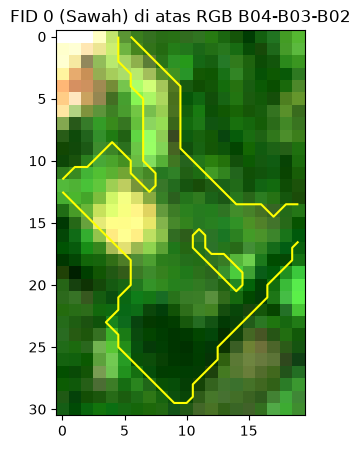


TABEL RINGKASAN — FID 500


Atribut,Nilai
FID,500
Class ID,2
Class name,Bangunan / Permukiman
Luas (m2),"5,735"
Pixel valid (centroid),59
Pixel valid (all_touched),80
Pixel dalam geom tapi nodata,0


TABEL PIXEL — FID 500 (10 pertama dari 59)


pixel_id,row,col,B02,B03,B04,B08,B11,B12
0,35213,19280,1238,1486,1540,2108,2328,1765
1,35213,19281,1646,1532,1628,1992,2645,2157
2,35213,19282,946,1136,1376,1936,2645,2157
3,35213,19283,780,1064,1108,2642,2282,1668
4,35213,19284,593,728,705,2878,2282,1668
5,35213,19285,552,826,780,2688,1939,1200
6,35214,19280,982,1294,1472,2170,2567,2088
7,35214,19281,1014,1204,1332,1908,2781,2427
8,35214,19282,1018,1058,1238,1910,2781,2427
9,35214,19283,720,938,1052,2140,2678,2381


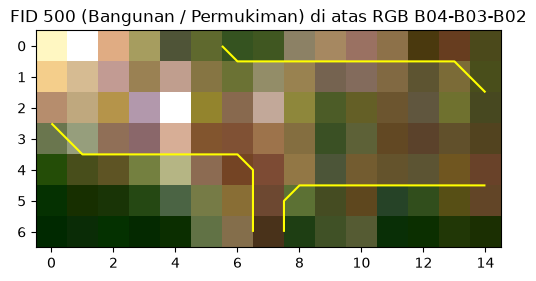


TABEL RINGKASAN — FID 1001


Atribut,Nilai
FID,1001
Class ID,3
Class name,Mangrove
Luas (m2),213
Pixel valid (centroid),2
Pixel valid (all_touched),4
Pixel dalam geom tapi nodata,0


TABEL PIXEL — FID 1001 (2 pertama dari 2)


pixel_id,row,col,B02,B03,B04,B08,B11,B12
0,21692,20354,1324,1508,1466,3564,2319,1994
1,21693,20354,1454,1766,1774,3652,2319,1994


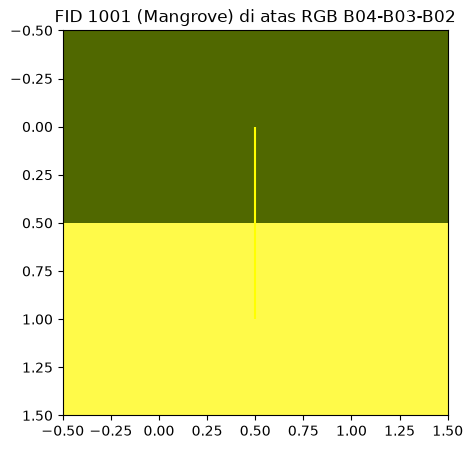


TABEL RINGKASAN — FID 1500


Atribut,Nilai
FID,1500
Class ID,4
Class name,Lahan hijau
Luas (m2),"3,888"
Pixel valid (centroid),38
Pixel valid (all_touched),50
Pixel dalam geom tapi nodata,0


TABEL PIXEL — FID 1500 (10 pertama dari 38)


pixel_id,row,col,B02,B03,B04,B08,B11,B12
0,30159,37550,276,574,444,3152,2108,1223
1,30160,37550,376,580,719,2498,2108,1223
2,30160,37551,252,499,391,3124,2108,1223
3,30160,37552,208,440,314,3164,1762,945
4,30160,37553,197,373,254,3054,1762,945
5,30161,37550,526,802,998,2492,2408,1479
6,30161,37551,362,648,688,2490,2408,1479
7,30161,37552,286,556,494,3022,1841,970
8,30161,37553,201,442,306,3086,1841,970
9,30161,37554,185,436,236,2958,1763,857


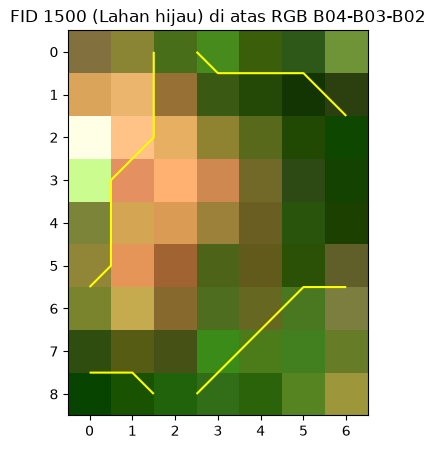


TABEL RINGKASAN — FID 2025


Atribut,Nilai
FID,2025
Class ID,5
Class name,Laut
Luas (m2),"25,077,484"
Pixel valid (centroid),"31,663"
Pixel valid (all_touched),"31,893"
Pixel dalam geom tapi nodata,"219,108"


TABEL PIXEL — FID 2025 (10 pertama dari 31663)


pixel_id,row,col,B02,B03,B04,B08,B11,B12
0,40169,40503,280,471,373,3000,1547,715
1,40170,40503,233,430,287,2644,1547,715
2,40170,40504,280,486,325,3020,1927,1007
3,40171,40503,245,460,292,2908,1473,645
4,40171,40504,248,488,320,3022,1534,665
5,40171,40505,247,490,345,2774,1534,665
6,40172,40503,222,410,245,3002,1473,645
7,40172,40504,254,482,319,3046,1534,665
8,40172,40505,299,505,326,3200,1534,665
9,40173,40503,215,433,227,3084,1545,650


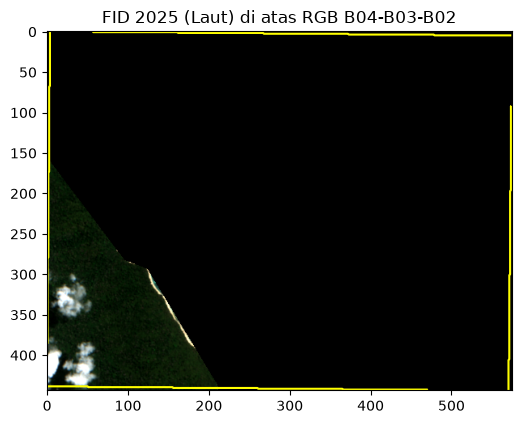


TABEL RINGKASAN — FID 2552


Atribut,Nilai
FID,2552
Class ID,6
Class name,Danau
Luas (m2),"23,275"
Pixel valid (centroid),230
Pixel valid (all_touched),314
Pixel dalam geom tapi nodata,0


TABEL PIXEL — FID 2552 (10 pertama dari 230)


pixel_id,row,col,B02,B03,B04,B08,B11,B12
0,34618,17143,464,680,598,2834,1960,1282
1,34619,17142,580,832,720,2554,2182,1398
2,34619,17143,648,803,739,2192,1960,1282
3,34619,17144,712,898,830,2448,1960,1282
4,34619,17145,662,880,870,2402,1736,1157
5,34620,17141,571,786,696,2972,1931,1144
6,34620,17142,584,806,726,2634,1931,1144
7,34620,17143,623,800,790,1936,1589,1092
8,34620,17144,780,880,958,1558,1589,1092
9,34620,17145,738,819,868,1762,1387,991


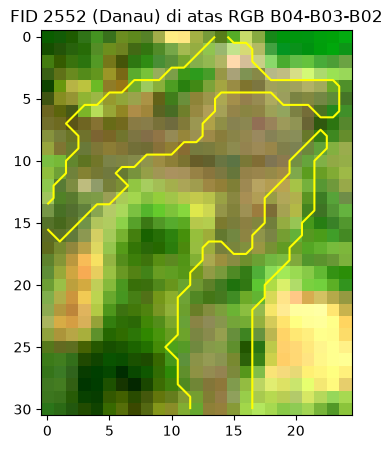

In [33]:
# DATA AKTUAL PROJECT — 2.8b detail tiap contoh + tabel pixel aktual + centroid vs all_touched + overlay RGB.
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
from rasterio.features import geometry_mask
from rasterio.windows import from_bounds
from IPython.display import display, HTML

# LOAD DATA
BANDS = ["B02", "B03", "B04", "B08", "B11", "B12"]
g = gpd.read_file("../data/training_samples_jawa_timur.geojson")
stat = pd.read_csv("../outputs/tables/polygon_pixel_stats.csv")
ex = pd.read_csv("../outputs/tables/contoh_fid.csv")

fids = [int(f) for f in ex["fid"].tolist() if pd.notna(f)]
if 367 in set(g["fid"].tolist()) and 367 not in fids:
    fids = [367] + fids

# LOOP PER FID
with rasterio.open("../data/s2_jatim.tif") as src:
    gu = g.to_crs(src.crs)

    for fid in fids:
        row = gu[gu["fid"] == fid].iloc[0]
        geom, cid, cn = row["geometry"], int(row["class_id"]), row["class_name"]
        nrow = stat[stat["fid"] == fid].iloc[0]

        w = from_bounds(*geom.bounds, src.transform).crop(src.height, src.width)
        arr = src.read(window=w, boundless=True, fill_value=src.nodata)
        t = src.window_transform(w)

        mc = geometry_mask([geom], out_shape=(arr.shape[1], arr.shape[2]),
                           transform=t, invert=True, all_touched=False)
        ma = geometry_mask([geom], out_shape=(arr.shape[1], arr.shape[2]),
                           transform=t, invert=True, all_touched=True)

        okc = mc & (arr != src.nodata).all(axis=0)
        oka = ma & (arr != src.nodata).all(axis=0)

        # PERBAIKAN: set crs=src.crs agar tidak naive
        luas_m2 = float(gpd.GeoSeries([geom], crs=src.crs)
                        .to_crs("EPSG:32749").area.values[0])
        n_nodata = int(mc.sum()) - int(okc.sum())

        # TABEL RINGKASAN PER FID
        ringkas = pd.DataFrame({
            "Atribut": [
                "FID", "Class ID", "Class name",
                "Luas (m2)",
                "Pixel valid (centroid)",
                "Pixel valid (all_touched)",
                "Pixel dalam geom tapi nodata",
            ],
            "Nilai": [
                f"{fid}",
                f"{cid}",
                f"{cn}",
                f"{luas_m2:,.0f}",
                f"{int(okc.sum()):,}",
                f"{int(oka.sum()):,}",
                f"{n_nodata:,}",
            ],
        })
        print(f"\nTABEL RINGKASAN — FID {fid}")
        display(HTML(ringkas.to_html(index=False, justify="left", border=1)))

        # TABEL PIXEL (10 pertama)
        rr, cc = np.where(okc)
        n_tampil = min(10, len(rr))
        rows = []
        for k in range(n_tampil):
            vals = arr[:, rr[k], cc[k]].tolist()
            rows.append({
                "pixel_id": k,
                "row": int(rr[k] + w.row_off),
                "col": int(cc[k] + w.col_off),
                **{b: v for b, v in zip(BANDS, vals)},
            })
        pixel_tab = pd.DataFrame(rows)

        print(f"TABEL PIXEL — FID {fid} ({n_tampil} pertama dari {int(okc.sum())})")
        display(HTML(pixel_tab.to_html(index=False, justify="left", border=1)))

        # OVERLAY RGB
        rgb = np.stack([arr[2], arr[1], arr[0]]).astype(float)
        base = rgb[rgb > 0] if (rgb > 0).any() else rgb
        lo, hi = np.percentile(base, [2, 98])

        fig, ax = plt.subplots(figsize=(6, 5))
        ax.imshow(np.clip((rgb - lo) / max(hi - lo, 1), 0, 1).transpose(1, 2, 0))
        ax.contour(mc, levels=[0.5], colors="yellow", linewidths=1.5)
        ax.set_title(f"FID {fid} ({cn}) di atas RGB B04-B03-B02")
        plt.savefig(f"../outputs/figures/contoh_fid_{fid}.png", dpi=110, bbox_inches="tight")
        plt.show()

**Interpretasi 2.8:** `all_touched=True` cenderung menambah pixel tepi (termasuk mixed pixel) dibanding aturan centroid; selisihnya dibaca dari angka tiap contoh. Aturan final (centroid) dipakai konsisten di seluruh pipeline dan dicatat di metadata model (Tahap 3–4).

## 2.9 Dataset pixel-based: konsep dan statistik

Satu polygon → banyak pixel → banyak sample. Tiga indeks (formula acuan umum, bukan data project):

```
NDVI = (B08 - B04) / (B08 + B04)   # vegetasi
NDWI = (B03 - B08) / (B03 + B08)   # air (McFeeters); dapat tinggi pada bayangan/area basah selain air
NDBI = (B11 - B08) / (B11 + B08)   # area terbangun
```

Penyebut nol dan nodata ditangani dengan mask (pixel tak terdefinisi dikeluarkan dan dihitung).

In [35]:
# DATA AKTUAL PROJECT — 2.9 jumlah pixel valid per polygon valid-geometri; invalid: 'tidak dihitung'.
import pandas as pd
from IPython.display import display, HTML

# LOAD & MERGE
g = pd.read_pickle("../outputs/tables/validity_v1v4v6.pkl")
stat = pd.read_csv("../outputs/tables/polygon_pixel_stats.csv")
h = g.merge(stat, on="fid", how="left")

hitung = h[h["n_valid"] >= 0]
n_tidak_hitung = int((h["n_valid"] < 0).sum())

# TABEL 1 — Ringkasan status perhitungan
status_tab = pd.DataFrame({
    "Status": ["Dihitung", "Tidak dihitung (invalid)"],
    "Jumlah polygon": [f"{len(hitung):,}", f"{n_tidak_hitung:,}"],
})
print("TABEL 1 — Status perhitungan pixel")
display(HTML(status_tab.to_html(index=False, justify="left", border=1)))

# TABEL 2 — Statistik pixel per kelas
tab = (hitung.groupby(["class_id", "class_name"])["n_valid"]
             .agg(["count", "sum", "mean", "median", "min", "max"])
             .reset_index()
             .rename(columns={
                 "count": "polygon_count",
                 "sum": "total_pixels",
                 "mean": "mean_pixels",
                 "median": "median_pixels",
                 "min": "min_pixels",
                 "max": "max_pixels",
             }))

for c in ["mean_pixels", "median_pixels"]:
    tab[c] = tab[c].round(1)
for c in ["total_pixels", "min_pixels", "max_pixels"]:
    tab[c] = tab[c].apply(lambda v: f"{int(v):,}")

print("\nTABEL 2 — Statistik pixel valid per kelas")
display(HTML(tab.to_html(index=False, justify="left", border=1)))

# TABEL 3 — Polygon dengan 0 pixel valid
nol = hitung[hitung["n_valid"] == 0][["fid", "class_id", "class_name", "status_v5"]].copy()
nol["fid"] = nol["fid"].astype(int)

print(f"\nTABEL 3 — Polygon dengan 0 pixel valid (total {len(nol)})")
display(HTML(nol.head(20).to_html(index=False, justify="left", border=1)))

if len(nol) > 20:
    print(f"Ditampilkan 20 dari {len(nol)} baris.")

TABEL 1 — Status perhitungan pixel


Status,Jumlah polygon
Dihitung,"2,776"
Tidak dihitung (invalid),47



TABEL 2 — Statistik pixel valid per kelas


class_id,class_name,polygon_count,total_pixels,mean_pixels,median_pixels,min_pixels,max_pixels
1,Sawah,495,"171,808",347.1,0.0,0,"34,990"
2,Bangunan / Permukiman,498,"85,827",172.3,10.0,0,"5,718"
3,Mangrove,465,"92,671",199.3,0.0,0,"24,605"
4,Lahan hijau,495,"10,332,099",20872.9,0.0,0,"8,879,967"
5,Laut,500,"46,143",92.3,0.0,0,"31,663"
6,Danau,323,"24,347",75.4,10.0,0,"3,620"



TABEL 3 — Polygon dengan 0 pixel valid (total 2008)


fid,class_id,class_name,status_v5
1,1,Sawah,V5: <1 pixel valid
2,1,Sawah,V5: <1 pixel valid
3,1,Sawah,V5: <1 pixel valid
4,1,Sawah,V5: <1 pixel valid
6,1,Sawah,V5: <1 pixel valid
7,1,Sawah,V5: <1 pixel valid
8,1,Sawah,V5: <1 pixel valid
9,1,Sawah,V5: <1 pixel valid
10,1,Sawah,V5: <1 pixel valid
11,1,Sawah,V5: <1 pixel valid


Ditampilkan 20 dari 2008 baris.


**Interpretasi 2.9:** median 0 pada 4 dari 6 kelas — distribusi pixel sangat menjulur (maksimum Lahan hijau 8879967 vs median 0). Dari 2776 polygon yang dihitung, 2008 ber-nol pixel. Dominasi polygon raksasa inilah alasan capping 500 di Tahap 3. Dataset final dibentuk di Tahap 3.

## 2.10 Dataset polygon-mean: konsep dan contoh

Satu polygon → semua pixel valid → rata-rata → satu sample. Keputusan definisi (dicatat, dipakai konsisten): indeks dihitung **dari mean band** (bukan mean dari indeks pixel), karena satu sample diwakili satu vektor band mean. Nodata dikeluarkan sebelum mean; penyebut nol pada indeks → indeks "tidak terdefinisi" untuk polygon itu dan dihitung.

In [36]:
# DATA AKTUAL PROJECT — 2.10 contoh mean aktual (semua pixel valid, tanpa cap).
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.features import geometry_mask
from rasterio.windows import from_bounds

BANDS = ["B02", "B03", "B04", "B08", "B11", "B12"]
g = gpd.read_file("../data/training_samples_jawa_timur.geojson")
fid = 367 if 367 in set(g["fid"].tolist()) else int(pd.read_csv("../outputs/tables/contoh_fid.csv")["fid"].iloc[0])
with rasterio.open("../data/s2_jatim.tif") as src:
    row = g.to_crs(src.crs)
    row = row[row["fid"] == fid].iloc[0]
    w = from_bounds(*row["geometry"].bounds, src.transform).crop(src.height, src.width)
    arr = src.read(window=w, boundless=True, fill_value=src.nodata)
    m = geometry_mask([row["geometry"]], out_shape=(arr.shape[1], arr.shape[2]),
                        transform=src.window_transform(w), invert=True, all_touched=False)
    vals = arr[:, m & (arr != src.nodata).all(axis=0)].T.astype(float)
    mean = vals.mean(axis=0)
    print(f"FID: {fid}\nClass: {int(row['class_id'])} {row['class_name']} (n_pixel_valid={len(vals)})")
    for b_, v in zip(BANDS, mean):
        print(f"mean_{b_} = {v:.1f}")
    d = dict(zip(BANDS, mean))
    ndvi = (d["B08"] - d["B04"]) / (d["B08"] + d["B04"]) if (d["B08"] + d["B04"]) != 0 else float("nan")
    ndwi = (d["B03"] - d["B08"]) / (d["B03"] + d["B08"]) if (d["B03"] + d["B08"]) != 0 else float("nan")
    ndbi = (d["B11"] - d["B08"]) / (d["B11"] + d["B08"]) if (d["B11"] + d["B08"]) != 0 else float("nan")
    print(f"DATA AKTUAL PROJECT: NDVI_dari_mean = {ndvi:.3f}, NDWI_dari_mean = {ndwi:.3f}, NDBI_dari_mean = {ndbi:.3f}")

FID: 367
Class: 1 Sawah (n_pixel_valid=40)
mean_B02 = 359.0
mean_B03 = 579.9
mean_B04 = 502.2
mean_B08 = 2560.1
mean_B11 = 1846.4
mean_B12 = 1128.2
DATA AKTUAL PROJECT: NDVI_dari_mean = 0.672, NDWI_dari_mean = -0.631, NDBI_dari_mean = -0.162


**Interpretasi 2.10:** satu polygon (FID 367, Sawah, 40 pixel) diringkas menjadi satu vektor mean + indeks-dari-mean — tanpa menyimpulkan pendekatan ini lebih baik dari pixel-based. Perbandingan hanya dijawab dari hasil Bab 4-5.

## 2.11 Visualisasi

Setiap visual dijelaskan: apa yang terlihat dan apa yang bisa dipelajari.

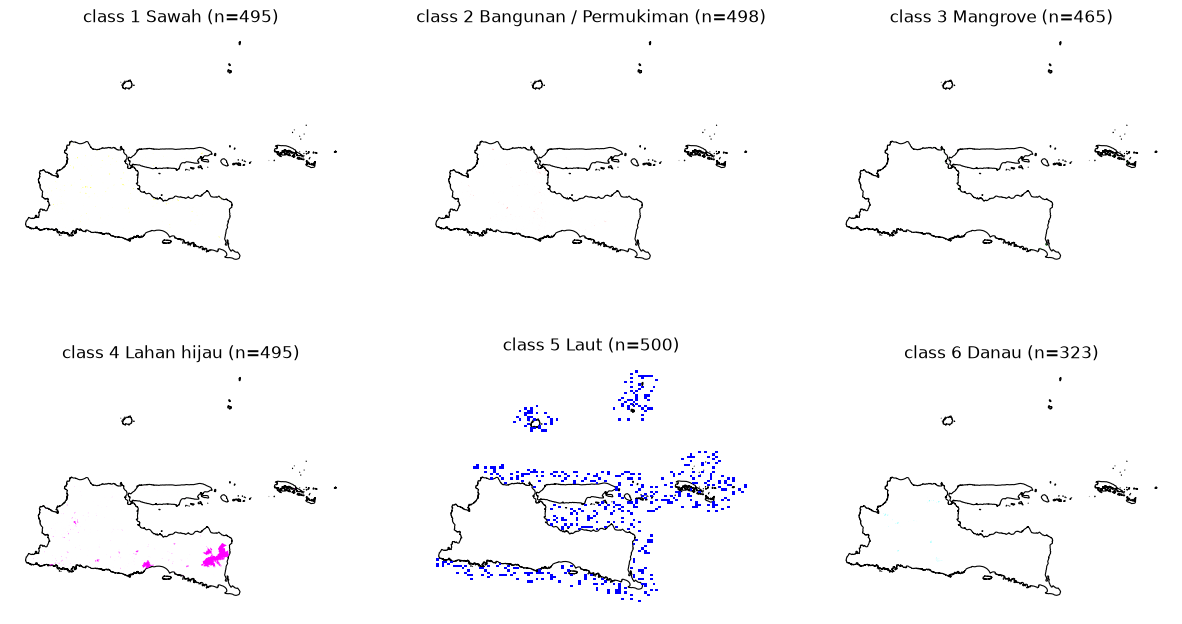

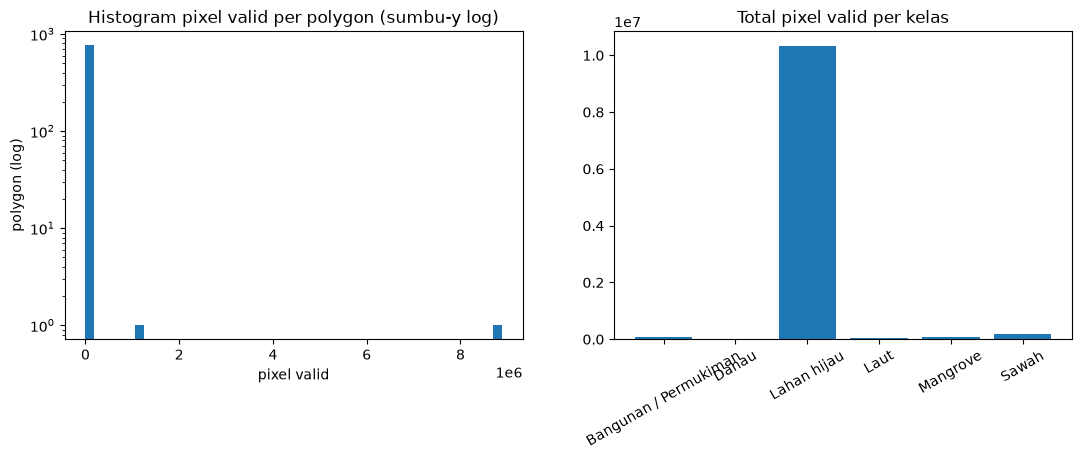

DATA AKTUAL PROJECT: histogram dari 768 polygon (n_valid>0)


In [37]:
# DATA AKTUAL PROJECT — 2.11a sebaran polygon per kelas + histogram + distribusi + profil spektral + boxplot.
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

bj = gpd.read_file("../data/boundary_jatim.geojson")
g = pd.read_pickle("../outputs/tables/validity_v1v4v6.pkl")
stat = pd.read_csv("../outputs/tables/polygon_pixel_stats.csv")
gv = g[(g["kode"] == "VALID")].copy()
WARNA = {1: "#FFFF00", 2: "#FF0000", 3: "#00FF00", 4: "#FF00FF", 5: "#0000FF", 6: "#00FFFF"}
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, cid in zip(axes.ravel(), [1, 2, 3, 4, 5, 6]):
    bj.plot(ax=ax, edgecolor="black", facecolor="none", linewidth=0.8)
    sub = gv[gv["class_id"] == cid]
    sub.plot(ax=ax, color=WARNA[cid], markersize=4)
    cn = sub["class_name"].iloc[0] if len(sub) else "?"
    ax.set_title(f"class {cid} {cn} (n={len(sub)})")
    ax.set_axis_off()
plt.savefig("../outputs/figures/sebaran_per_kelas.png", dpi=110, bbox_inches="tight")
plt.show()
h = gv.merge(stat, on="fid", how="left")
h = h[h["n_valid"] > 0]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(h["n_valid"], bins=50, log=True)
axes[0].set_title("Histogram pixel valid per polygon (sumbu-y log)")
axes[0].set_xlabel("pixel valid"); axes[0].set_ylabel("polygon (log)")
tot = h.groupby("class_name")["n_valid"].sum()
axes[1].bar(tot.index, tot.values)
axes[1].set_title("Total pixel valid per kelas")
axes[1].tick_params(axis="x", rotation=30)
plt.savefig("../outputs/figures/hist_distribusi_pixel.png", dpi=110, bbox_inches="tight")
plt.show()
print(f"DATA AKTUAL PROJECT: histogram dari {len(h)} polygon (n_valid>0)")

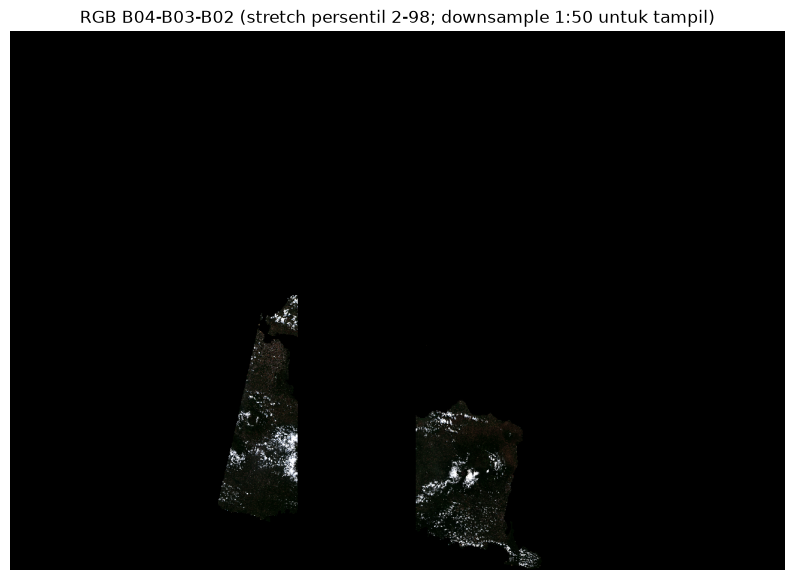

DATA AKTUAL PROJECT: stretch p2=173 p98=8224 (dari data tampil)


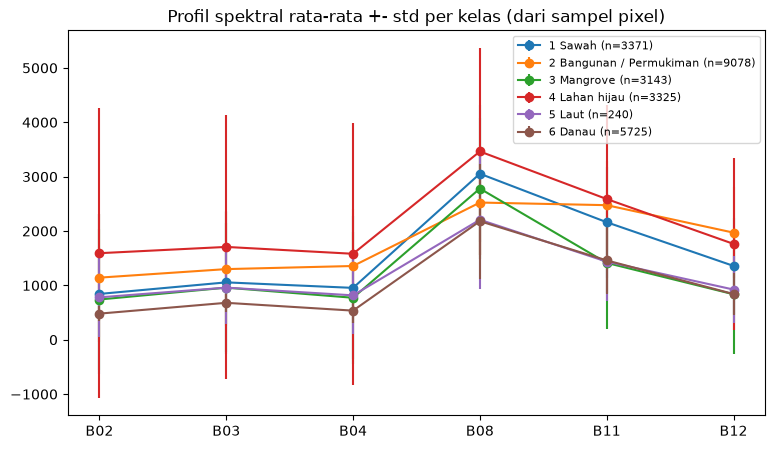

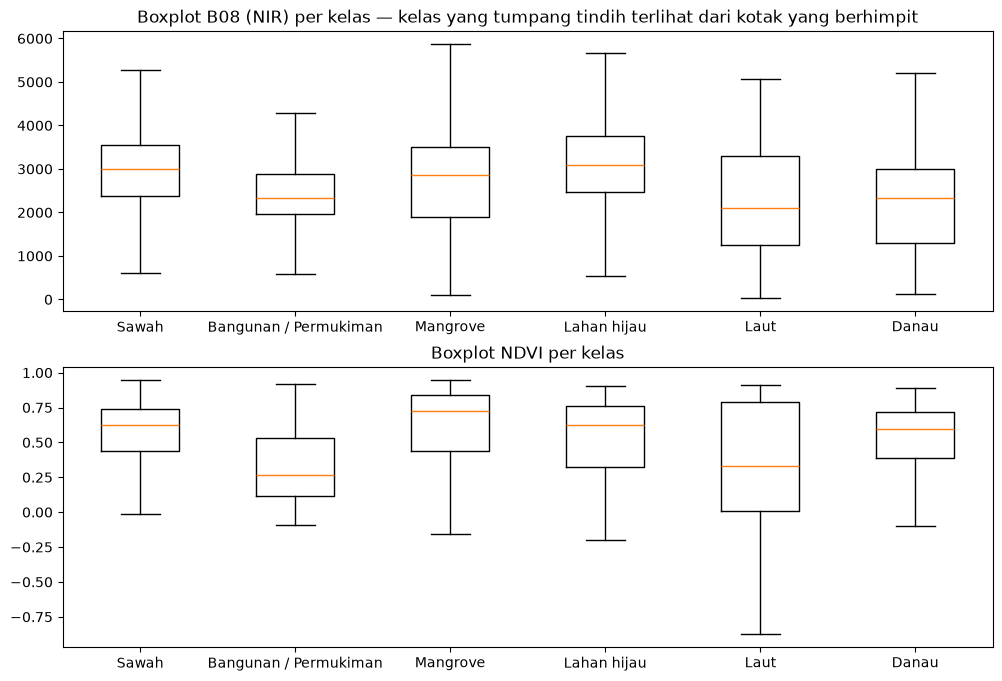

In [44]:
# DATA AKTUAL PROJECT — 2.11b RGB seluruh raster (downsample) + profil spektral + boxplot dari sampel kelas.
import numpy as np
import matplotlib.pyplot as plt
import rasterio

BANDS = ["B02", "B03", "B04", "B08", "B11", "B12"]
CN = {1: "Sawah", 2: "Bangunan / Permukiman", 3: "Mangrove", 4: "Lahan hijau", 5: "Laut", 6: "Danau"}

with rasterio.open("../data/s2_jatim.tif") as src:
    rgb = src.read([3, 2, 1], out_shape=(3, src.height // 50, src.width // 50)).astype(float)
    lo, hi = np.percentile(rgb[rgb > 0], [2, 98])
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.imshow(np.clip((rgb - lo) / (hi - lo), 0, 1).transpose(1, 2, 0))
    ax.set_title("RGB B04-B03-B02 (stretch persentil 2-98; downsample 1:50 untuk tampil)")
    ax.set_axis_off()
    plt.savefig("../outputs/figures/rgb_jatim.png", dpi=110, bbox_inches="tight")
    plt.show()
    print(f"DATA AKTUAL PROJECT: stretch p2={lo:.0f} p98={hi:.0f} (dari data tampil)")

z = np.load("../outputs/tables/class_pixel_sample.npz")

fig, ax = plt.subplots(figsize=(9, 5))
for c in [1, 2, 3, 4, 5, 6]:
    v = z[f"c{c}"].astype(float)
    ax.errorbar(BANDS, v.mean(axis=0), yerr=v.std(axis=0), marker="o", label=f"{c} {CN[c]} (n={len(v)})")
ax.set_title("Profil spektral rata-rata +- std per kelas (dari sampel pixel)")
ax.legend(fontsize=8)
plt.savefig("../outputs/figures/profil_spektral.png", dpi=110, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
data_b = [z[f"c{c}"][:, 3].astype(float) for c in [1, 2, 3, 4, 5, 6]]
axes[0].boxplot(data_b, tick_labels=[CN[c] for c in [1, 2, 3, 4, 5, 6]], showfliers=False)
axes[0].set_title("Boxplot B08 (NIR) per kelas — kelas yang tumpang tindih terlihat dari kotak yang berhimpit")

idx = {}
for c in [1, 2, 3, 4, 5, 6]:
    v = z[f"c{c}"].astype(float)
    den = v[:, 3] + v[:, 2]
    idx[c] = np.where(den != 0, (v[:, 3] - v[:, 2]) / np.where(den == 0, 1, den), np.nan)

axes[1].boxplot(
    [idx[c][~np.isnan(idx[c])] for c in [1, 2, 3, 4, 5, 6]],
    tick_labels=[CN[c] for c in [1, 2, 3, 4, 5, 6]],
    showfliers=False,
)
axes[1].set_title("Boxplot NDVI per kelas")
plt.savefig("../outputs/figures/boxplot_b08_ndvi.png", dpi=110, bbox_inches="tight")
plt.show()

In [45]:
# DATA AKTUAL PROJECT — 2.11c peta interaktif: boundary sebagai border + 6 layer kelas (checkbox).
import geopandas as gpd
import folium

WARNA = {1: "#FFFF00", 2: "#FF0000", 3: "#00FF00", 4: "#FF00FF", 5: "#0000FF", 6: "#00FFFF"}
CN = {1: "Sawah", 2: "Bangunan / Permukiman", 3: "Mangrove", 4: "Lahan hijau", 5: "Laut", 6: "Danau"}

bj = gpd.read_file("../data/boundary_jatim.geojson").to_crs("EPSG:4326")
g = gpd.read_file("../data/training_samples_jawa_timur.geojson").to_crs("EPSG:4326")

bb = bj.total_bounds  # tengah dari bounds (menghindari warning centroid pada CRS geografis)
m = folium.Map(location=[(bb[1] + bb[3]) / 2, (bb[0] + bb[2]) / 2], zoom_start=7)
folium.TileLayer(tiles="https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}",
                 attr="Google Satellite", name="Google Satellite",
                 overlay=False, control=True).add_to(m)

folium.GeoJson(
    bj.__geo_interface__,
    name="Batas Jatim",
    style_function=lambda f: {"color": "black", "weight": 2.5, "fill": False},
).add_to(m)

for cid in [1, 2, 3, 4, 5, 6]:
    sub = g[g["class_id"] == cid].copy()
    sub["geometry"] = sub.geometry.simplify(0.0005)
    fg = folium.FeatureGroup(name=f"{cid} {CN[cid]} (n={len(sub)})")
    folium.GeoJson(
        sub.__geo_interface__,
        style_function=lambda f, w=WARNA[cid]: {
            "color": w, "weight": 1, "fillColor": w, "fillOpacity": 0.5,
        },
        tooltip=folium.GeoJsonTooltip(fields=["fid", "class_name"]),
    ).add_to(fg)
    fg.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

out_path = "../outputs/figures/folium_polygon_map.html"
m.save(out_path)
print(f"DATA AKTUAL PROJECT: folium tersimpan (6 layer, total polygon={len(g)})")
m

DATA AKTUAL PROJECT: folium tersimpan (6 layer, total polygon=2823)


**Catatan basemap:** bawaan OpenStreetMap; alihkan ke **Google Satellite** lewat kontrol layer (kanan atas) untuk memeriksa polygon di atas citra. Peta interaktif di atas tersimpan juga di `outputs/figures/folium_polygon_map.html`.

**Interpretasi 2.11:** peta sebaran memakai polygon berkode VALID. Histogram memakai 768 polygon (`n_valid>0`). RGB memakai stretch persentil 2-98 (p2=173, p98=8224 dari data tampil). Profil spektral/boxplot dari sampel maksimal 6000 pixel per kelas — kelas dengan kotak berhimpit (terutama di NIR/NDVI) menandai kesulitan spektral, bukan vonis tak terpisahkan. Peta folium: 6 layer checkbox warna kontras + border boundary hitam + pilihan basemap OpenStreetMap/Google Satellite; titik tengah peta dari bounds (tanpa warning centroid) dan tidak memengaruhi data.

## 2.12 Kesimpulan data understanding (hanya fakta)

- Mentah: 2823 polygon (kelas 1-5 masing-masing 500, Danau 323); semua bertipe Polygon; isi geojson dan gpkg identik (beda: kolom `fid` hanya di geojson).
- Validitas: V1-V4 = 0; V6 = 47 (Mangrove 35); V5 = 1901 (termasuk 107 di luar extent yang masih berkode VALID dengan `n_valid=0`). VALID final = 875.
- Pool berkode VALID vs 50: Sawah 88, Bangunan 252, Mangrove 155, Lahan hijau 118, Laut 32, Danau 230. Koreksi Bab 3: 107 di antaranya `n_valid=0`, sehingga pool berpixel: 88/252/108/101/6/213 — Laut hanya 6, seleksi maksimal 256 polygon.
- Pixel: median 0 di 4 kelas; 2008 polygon nol-pixel; Lahan hijau mendominasi (satu polygon ~8,9 juta pixel) sehingga capping 500 diperlukan di Tahap 3.
- Citra: komposit median 6 band 10 m, 2025-09-01 s.d. 2025-09-02; B11/B12 terindikasi resample; metode tidak tercatat.
- Risiko: label noise (beda tahun sumber vs citra, snapshot 2 hari), mixed pixel tepi (aturan centroid tercatat), kelas spektral tumpang tindih.
- Tidak disimpulkan pixel-based atau polygon-mean lebih baik.

**Kontrak untuk Tahap 3 (agar berjalan apa adanya, tanpa asumsi 300):** baca `polygon_validity_diagnostic.csv` + `polygon_pixel_stats.csv`; saring `kode==VALID` DAN `n_valid>0`; ambil acak reproducible maksimal 50 per kelas (Laut: seluruh 6 yang berpixel); tanpa data baru.

## Checkpoint Tahap 2

- Notebook ter-eksekusi (satu catatan: sel 2.1 ber-`execution_count=None` sehingga tampil `In [ ]` meski output tersimpan — butuh run ulang satu sel itu bila ingin nomor urut penuh; isi tidak berubah).
- Tabel validitas per kelas tersedia (`polygon_validity_diagnostic.csv`).
- FID 367 TERSEDIA (Sawah, VALID, 40 pixel valid).
- Temporal metadata cocok dengan 0.5 (`cocok_0.5 = True`).